# Исследование распределения длин токенов по классам

## Загрузка данных

In [1]:
MODEL_NAME = "cointegrated/rubert-tiny2"

In [2]:
from datasets import load_dataset
from transformers import AutoTokenizer

c:\Users\User\Documents\VScode projects\coursework-reviewer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

dataset = load_dataset(r"C:\Users\User\Documents\VScode projects\coursework-reviewer\data\processed", split="train")

In [4]:
dataset[0]

{'label': 'paragraph',
 'doc_id': 'hramov_am_upravlenie-adaptaciey-trudovyh-migrantov-zanyatyh-v-sfere-roznichnoy-torgovli-s-pomoshchyu-cifrovyh-teh_316779',
 'block_id': 643,
 'text': 'Таким образом, более половины мигрантов (56%) используют цифровые платформы для трудоустройства, что говорит об увеличении роли интернета в процессе адаптации.',
 'needs_review': False,
 'label_id': 0,
 'prev_text': None,
 'next_text': None,
 'is_negative': None,
 'is_after_figure': None}

## Токенизация

In [5]:
import torch

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def compute_len(example):
    inputs = tokenizer(example["text"], truncation=False)
    return {"token_len": len(inputs["input_ids"])}

stats_dataset = dataset.map(compute_len)


## Визуализация данных

In [7]:
import pandas as pd

df_stats = stats_dataset.to_pandas()[["label", "token_len"]]

In [8]:
distribution = df_stats.groupby("label")["token_len"].describe()
distribution

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
caption,673.0,20.120357,24.666986,4.0,13.0,18.0,23.0,607.0
heading,5983.0,11.957045,9.037738,2.0,7.0,10.0,14.0,107.0
paragraph,39096.0,92.352082,111.349518,13.0,40.0,68.0,113.0,7568.0


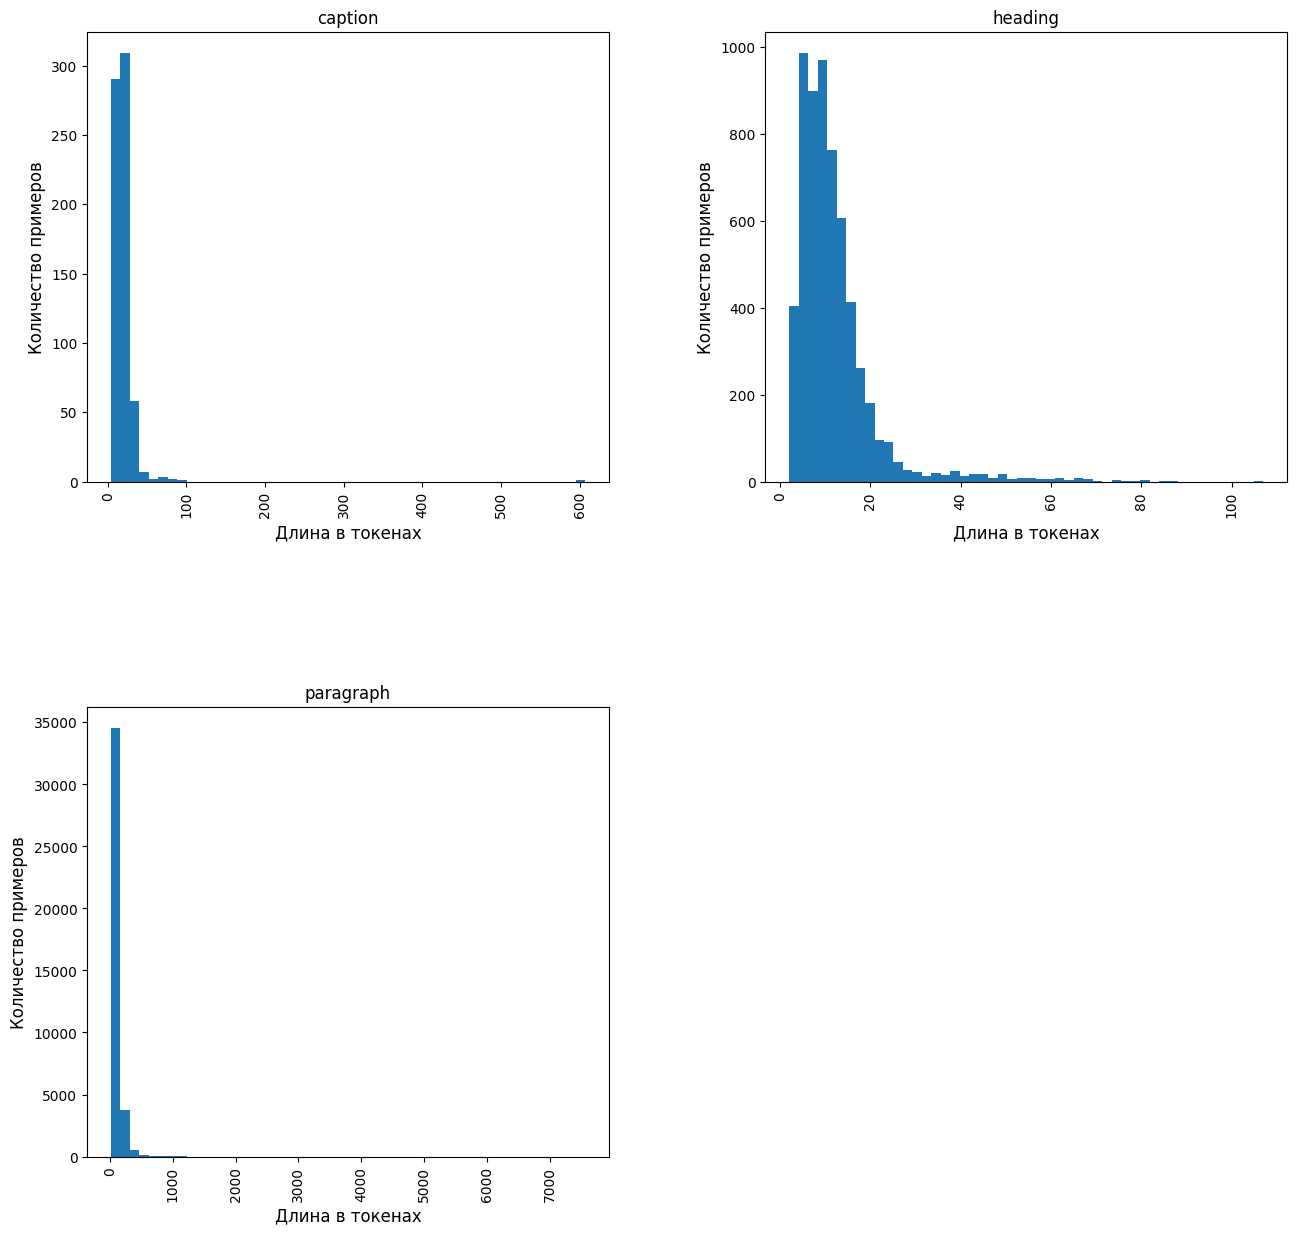

In [9]:
import matplotlib.pyplot as plt

axes = df_stats.hist(column="token_len", by="label", bins=50, figsize=(15, 15))

for ax in axes.flatten():
    ax.set_xlabel("Длина в токенах", fontsize=12)
    ax.set_ylabel("Количество примеров", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.show()

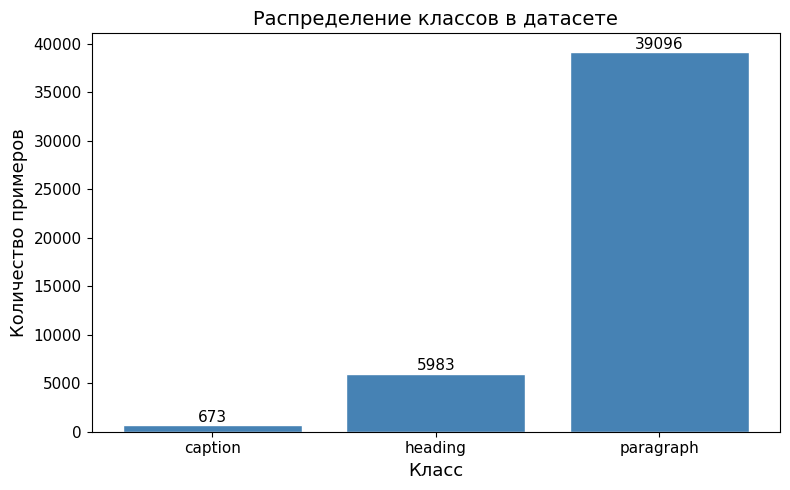

In [10]:
class_counts = df_stats["label"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_counts.index, class_counts.values, color="steelblue", edgecolor="white")

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(count), ha="center", va="bottom", fontsize=11)

ax.set_xlabel("Класс", fontsize=13)
ax.set_ylabel("Количество примеров", fontsize=13)
ax.set_title("Распределение классов в датасете", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=11)
plt.tight_layout()
plt.show()

## Аномалии

In [11]:
import pandas as pd

# 1. Для каждого класса выбираем топ-10 самых длинных текстов
top10_per_class = (
    df_stats.sort_values("token_len", ascending=False)
    .groupby("label")
    .head(10)
)

# 2. Создаем вспомогательный индекс (от 1 до 10) внутри каждой группы,
# чтобы строки в итоговой таблице выровнялись по рангу (1-е место, 2-е место и т.д.)
top10_per_class['rank'] = top10_per_class.groupby('label').cumcount() + 1

# 3. Разворачиваем таблицу так, чтобы метки стали колонками
final_table = top10_per_class.pivot(index='rank', columns='label', values='token_len')

# 4. Сортируем колонки по алфавиту для порядка
final_table = final_table.reindex(sorted(final_table.columns), axis=1)

# Выводим результат
print("ТОП-10 ДЛИН ТОКЕНОВ ПО КЛАССАМ")
print("-" * 30)
print(final_table)

# Если нужно сохранить в Excel или CSV для отчета:
# final_table.to_excel("top10_anomalies.xlsx")

ТОП-10 ДЛИН ТОКЕНОВ ПО КЛАССАМ
------------------------------
label  caption  heading  paragraph
rank                              
1          607      107       7568
2           96       87       5540
3           82       84       4612
4           80       81       4371
5           73       81       3776
6           72       81       3167
7           71       79       2721
8           64       76       2550
9           54       76       2510
10          52       74       2331


In [12]:

top10_indices = (
    df_stats.sort_values("token_len", ascending=False)
    .groupby("label")
    .head(10)
)

for label in sorted(top10_indices['label'].unique()):
    print(f"\n{'='*30}")
    print(f"КЛАСС: {label.upper()}")
    print(f"{'='*30}")
    
    class_anomalies = top10_indices[top10_indices['label'] == label]
    
    for i, (idx, row) in enumerate(class_anomalies.iterrows(), 1):
        full_text = stats_dataset[int(idx)]['text']
        length = row['token_len']
        
        print(f"\n--- Аномалия №{i} (Длина: {length} токенов) ---")
        if len(full_text) > 700:
            print(f"НАЧАЛО: {full_text[:500]}")
            print(f"--- [...] ---")
            print(f"КОНЕЦ: {full_text[-200:]}")
        else:
            print(full_text)
        print("-" * 50)


КЛАСС: CAPTION

--- Аномалия №1 (Длина: 607 токенов) ---
НАЧАЛО: Схема  Исследуемая реакция  ADDIN ZOTERO_ITEM CSL_CITATION {"citationID":"EG3vhGdF","properties":{"formattedCitation":"[1]","plainCitation":"[1]","noteIndex":0},"citationItems":[{"id":4,"uris":["http://zotero.org/users/local/iGctPNjv/items/2MT5Y26T"],"itemData":{"id":4,"type":"article-journal","abstract":"Single–carbon atom transfer reactions are lacking in organic synthesis, partly because of the absence of atomic carbon sources under standard solution-phase conditions. We report here that N-he
--- [...] ---
КОНЕЦ: Kodama","given":"Takuya"},{"family":"Tobisu","given":"Mamoru"}],"issued":{"date-parts":[["2023",2,3]]}}}],"schema":"https://github.com/citation-style-language/schema/raw/master/csl-citation.json"} [1]
--------------------------------------------------

--- Аномалия №2 (Длина: 96 токенов) ---
Рисунок 5 – Точность в разных наборах данных (FPB, FIQA, SEntFiN) в разных итерациях.Источник: Malandri L. et al. RE-FI

## Обрезка слишком длинных абзацев

In [13]:
dataset[0]

{'label': 'paragraph',
 'doc_id': 'hramov_am_upravlenie-adaptaciey-trudovyh-migrantov-zanyatyh-v-sfere-roznichnoy-torgovli-s-pomoshchyu-cifrovyh-teh_316779',
 'block_id': 643,
 'text': 'Таким образом, более половины мигрантов (56%) используют цифровые платформы для трудоустройства, что говорит об увеличении роли интернета в процессе адаптации.',
 'needs_review': False,
 'label_id': 0,
 'prev_text': None,
 'next_text': None,
 'is_negative': None,
 'is_after_figure': None}

In [14]:
from torch.utils.data import Dataset

class DocumentDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        if item["is_negative"] == True:
            item["label_id"] = 0
        text = item["text"]
        inputs = self.tokenizer(text, truncation=False)

        if len(inputs["input_ids"]) > 512:
            for key in inputs:
                inputs[key] = inputs[key][:128] + inputs[key][-386:]

        inputs["label"] = item["label_id"]      
        for key in inputs:
            inputs[key] = torch.tensor(inputs[key])
        
        return inputs
            

In [15]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding


doc_dataset = DocumentDataset(dataset, tokenizer)

data_collator = DataCollatorWithPadding(tokenizer, max_length=510)

# 1. создай DataLoader
dataloader = DataLoader(doc_dataset, batch_size=4, collate_fn=data_collator)

# 2. возьми один батч
batch = next(iter(dataloader))

print(batch)

{'input_ids': tensor([[    2,  9876,  5908,    16,  2445, 22969, 45944,    12,  1600,     9,
            13, 23774, 47138, 34100,   871, 63477,    16,  1046, 16667,  2514,
         46169,  9104, 38339,   314, 20991, 47006,    18,     3,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,  

c:\Users\User\Documents\VScode projects\coursework-reviewer\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:2356: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


# Расчет весов классов

In [16]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


labels = [i["label"].item() for i in doc_dataset]
classes = np.unique(labels)


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=labels
)
class_weights


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (5540 > 2048). Running this sequence through the model will result in indexing errors


array([ 0.3626621 ,  5.03821165, 22.66072313])

## Forward Pass


In [17]:
from transformers import AutoModelForSequenceClassification, AutoConfig

model_name = "cointegrated/rubert-tiny2"

num_classes = 3

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes
)

outputs = model(**batch)

outputs.logits

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 9469.90it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the ch

tensor([[-0.0825,  0.0504, -0.1021],
        [-0.0296,  0.0045, -0.0294],
        [-0.0353,  0.0431,  0.0238],
        [-0.1149,  0.0966,  0.0309]], grad_fn=<AddmmBackward0>)